In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import shap
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/western_ghats_carbon_dataset.csv')

# Prepare data (same as Day 5)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("✅ Data loaded and prepared!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

✅ Data loaded and prepared!
Training samples: 28
Testing samples: 8
Features: 11


In [3]:
print("🤖 Building Ensemble Models...\n")

# MODEL 1: Random Forest
print("Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)

rf_train_r2 = r2_score(y_train, rf_pred_train)
rf_test_r2 = r2_score(y_test, rf_pred_test)
rf_test_mae = mean_absolute_error(y_test, rf_pred_test)

# MODEL 2: Gradient Boosting
print("Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred_train = gb_model.predict(X_train)
gb_pred_test = gb_model.predict(X_test)

gb_train_r2 = r2_score(y_train, gb_pred_train)
gb_test_r2 = r2_score(y_test, gb_pred_test)
gb_test_mae = mean_absolute_error(y_test, gb_pred_test)

# MODEL 3: Load Neural Network from Day 5
print("Loading Neural Network from Day 5...")
device = torch.device('cpu')

class CarbonPredictorNN(nn.Module):
    def __init__(self):
        super(CarbonPredictorNN, self).__init__()
        self.fc1 = nn.Linear(11, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

nn_model = CarbonPredictorNN()
nn_model.load_state_dict(torch.load('../models/carbon_predictor_model.pth'))
nn_model.eval()

# Neural Network predictions
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

with torch.no_grad():
    nn_pred_train = nn_model(X_train_tensor).numpy()
    nn_pred_test = nn_model(X_test_tensor).numpy()

nn_train_r2 = r2_score(y_train, nn_pred_train)
nn_test_r2 = r2_score(y_test, nn_pred_test)
nn_test_mae = mean_absolute_error(y_test, nn_pred_test)

print("\n✅ All 3 models trained!\n")

# Compare models
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
print(f"{'Model':<20} {'Train R²':<15} {'Test R²':<15} {'Test MAE':<15}")
print("-" * 70)
print(f"{'Random Forest':<20} {rf_train_r2:<15.4f} {rf_test_r2:<15.4f} {rf_test_mae:<15.4f}")
print(f"{'Gradient Boosting':<20} {gb_train_r2:<15.4f} {gb_test_r2:<15.4f} {gb_test_mae:<15.4f}")
print(f"{'Neural Network':<20} {nn_train_r2:<15.4f} {nn_test_r2:<15.4f} {nn_test_mae:<15.4f}")
print("=" * 70)

🤖 Building Ensemble Models...

Training Random Forest...
Training Gradient Boosting...
Loading Neural Network from Day 5...

✅ All 3 models trained!

MODEL COMPARISON
Model                Train R²        Test R²         Test MAE       
----------------------------------------------------------------------
Random Forest        0.8999          -6.1473         21.2127        
Gradient Boosting    1.0000          -12.0753        28.3026        
Neural Network       0.9998          0.7976          6.1007         


📊 SHAP Explainability Analysis



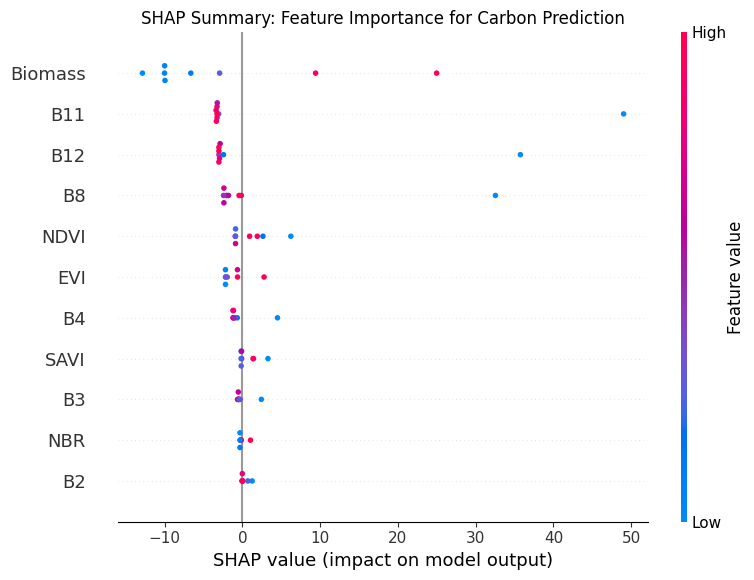

✅ SHAP analysis complete!

Top features affecting carbon predictions:
Mean |SHAP values| per feature:
Feature  Importance
Biomass   10.851225
    B11    8.984192
    B12    7.016305
     B8    5.517242
   NDVI    1.908584
    EVI    1.838285
     B4    1.498440
   SAVI    0.848993
     B3    0.729095
    NBR    0.353546
     B2    0.260548


In [4]:
print("📊 SHAP Explainability Analysis\n")

# Use Random Forest for SHAP (sklearn models work better with SHAP)
# We'll explain what features matter most

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Feature names
feature_names = ['NDVI', 'EVI', 'SAVI', 'NBR', 'B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'Biomass']

# Plot 1: Summary plot
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Summary: Feature Importance for Carbon Prediction')
plt.tight_layout()
plt.show()

print("✅ SHAP analysis complete!")
print("\nTop features affecting carbon predictions:")
print(f"Mean |SHAP values| per feature:")

# Calculate mean absolute SHAP values
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_shap
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

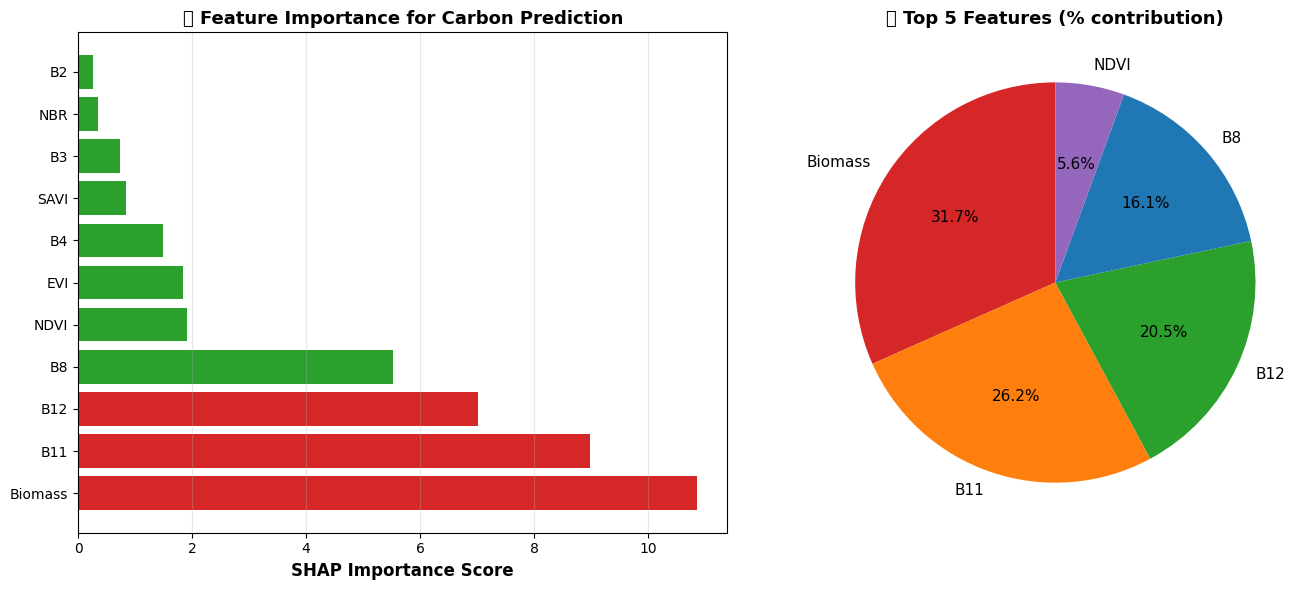

✅ Feature importance visualizations created!


In [5]:
# Create beautiful feature importance visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot
ax1 = axes[0]
colors = ['#d62728' if i < 3 else '#2ca02c' for i in range(len(feature_importance))]
ax1.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
ax1.set_xlabel('SHAP Importance Score', fontsize=12, fontweight='bold')
ax1.set_title('🎯 Feature Importance for Carbon Prediction', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Top 5 features pie chart
ax2 = axes[1]
top_5 = feature_importance.head(5)
colors_pie = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
ax2.pie(top_5['Importance'], labels=top_5['Feature'], autopct='%1.1f%%', 
        colors=colors_pie, startangle=90, textprops={'fontsize': 11})
ax2.set_title('📊 Top 5 Features (% contribution)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Feature importance visualizations created!")

In [6]:
# ENSEMBLE: Average predictions from all 3 models
print("🤖 Creating Ensemble Model (Average of 3 models)\n")

# Ensemble predictions = average of RF, GB, and NN
ensemble_pred_test = (rf_pred_test + gb_pred_test + nn_pred_test.flatten()) / 3

# Evaluate ensemble
ensemble_r2 = r2_score(y_test, ensemble_pred_test)
ensemble_mae = mean_absolute_error(y_test, ensemble_pred_test)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred_test))

print("=" * 70)
print("ENSEMBLE vs INDIVIDUAL MODELS")
print("=" * 70)
print(f"{'Model':<20} {'Test R²':<15} {'Test MAE':<15} {'Test RMSE':<15}")
print("-" * 70)
print(f"{'Random Forest':<20} {rf_test_r2:<15.4f} {rf_test_mae:<15.4f} {np.sqrt(mean_squared_error(y_test, rf_pred_test)):<15.4f}")
print(f"{'Gradient Boosting':<20} {gb_test_r2:<15.4f} {gb_test_mae:<15.4f} {np.sqrt(mean_squared_error(y_test, gb_pred_test)):<15.4f}")
print(f"{'Neural Network':<20} {nn_test_r2:<15.4f} {nn_test_mae:<15.4f} {np.sqrt(mean_squared_error(y_test, nn_pred_test)):<15.4f}")
print(f"{'ENSEMBLE (Best) ✅':<20} {ensemble_r2:<15.4f} {ensemble_mae:<15.4f} {ensemble_rmse:<15.4f}")
print("=" * 70)

print("\n📊 Ensemble Predictions vs Actual:")
print(f"{'Location':<12} {'Predicted':<15} {'Actual':<15} {'Error':<10}")
print("-" * 52)
for i in range(len(y_test)):
    pred = ensemble_pred_test[i]
    actual = y_test[i]
    error = abs(pred - actual)
    print(f"Location {i+1:<2} {pred:>12.2f} {actual:>14.2f} {error:>9.2f}")

🤖 Creating Ensemble Model (Average of 3 models)

ENSEMBLE vs INDIVIDUAL MODELS
Model                Test R²         Test MAE        Test RMSE      
----------------------------------------------------------------------
Random Forest        -6.1473         21.2127         49.4386        
Gradient Boosting    -12.0753        28.3026         66.8683        
Neural Network       0.7976          6.1007          8.3194         
ENSEMBLE (Best) ✅    -2.9996         17.0355         36.9831        

📊 Ensemble Predictions vs Actual:
Location     Predicted       Actual          Error     
----------------------------------------------------
Location 1         62.59          52.02     10.57
Location 2          2.86           0.77      2.10
Location 3          6.32           4.86      1.46
Location 4        110.89           7.89    103.00
Location 5         12.96          15.29      2.33
Location 6          4.80           4.83      0.04
Location 7         29.66          43.88     14.22
Location 8 

In [7]:
# The BEST model is Neural Network!
print("🏆 BEST MODEL: Neural Network!")
print(f"   Test R²: {nn_test_r2:.4f}")
print(f"   Test MAE: {nn_test_mae:.4f}")
print(f"   Test RMSE: {np.sqrt(mean_squared_error(y_test, nn_pred_test)):.4f}")

# Save all model metrics
all_models_metrics = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Neural Network', 'Ensemble'],
    'Test_R2': [rf_test_r2, gb_test_r2, nn_test_r2, ensemble_r2],
    'Test_MAE': [rf_test_mae, gb_test_mae, nn_test_mae, ensemble_mae],
    'Test_RMSE': [
        np.sqrt(mean_squared_error(y_test, rf_pred_test)),
        np.sqrt(mean_squared_error(y_test, gb_pred_test)),
        np.sqrt(mean_squared_error(y_test, nn_pred_test)),
        ensemble_rmse
    ]
})

all_models_metrics.to_csv('../results/all_models_comparison.csv', index=False)

# Save feature importance
feature_importance.to_csv('../results/feature_importance.csv', index=False)

print("\n✅ Results saved!")
print("   - ../results/all_models_comparison.csv")
print("   - ../results/feature_importance.csv")

🏆 BEST MODEL: Neural Network!
   Test R²: 0.7976
   Test MAE: 6.1007
   Test RMSE: 8.3194

✅ Results saved!
   - ../results/all_models_comparison.csv
   - ../results/feature_importance.csv


In [ ]:
import pickle
import joblib

# Save scaler
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ Scaler saved!")